# Chapter 6: Classical Extractor Metrics & Meta-RL Extractor 

Welcome to Chapter 5! This notebook guides you through how the first two tabs of the QRANDOPT dashboard work, in simple terms with practical examples.

## 1. Raw Bits Histogram 📊
The histogram shows how many 0s and 1s are in your bitstream. A perfectly random stream has about the same count of each.

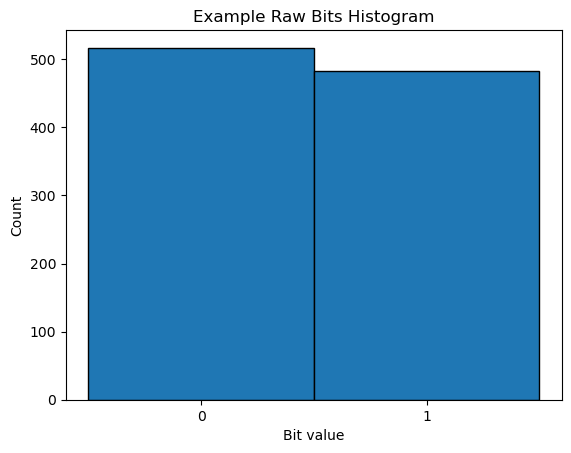

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate an example bitstream
data = np.random.randint(0, 2, size=1000)

# Plot histogram
plt.hist(data, bins=[-0.5, 0.5, 1.5], edgecolor='black')
plt.xticks([0, 1])
plt.title('Example Raw Bits Histogram')
plt.xlabel('Bit value')
plt.ylabel('Count')
plt.show()

## 2. Rolling Bias & Entropy 🔄
As bits stream in, we measure **bias** (difference from 50/50) and **entropy** (unpredictability) over a sliding window. Lower bias and higher entropy mean more randomness.

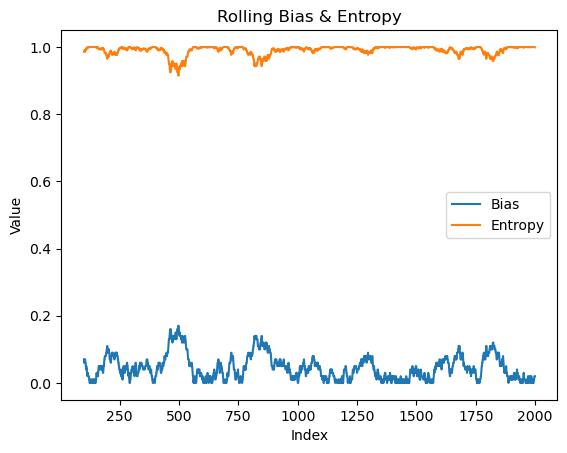

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate a bitstream
bits = np.random.randint(0, 2, size=2000)
window = 100

# Compute rolling bias
rolling_bias = pd.Series(bits).rolling(window).apply(lambda x: abs(x.mean() - 0.5))
# Compute rolling entropy
def sh_entropy(x):
    p = x.mean()
    return -(p * np.log2(p + 1e-9) + (1 - p) * np.log2(1 - p + 1e-9))
rolling_entropy = pd.Series(bits).rolling(window).apply(sh_entropy)

# Plot
plt.plot(rolling_bias, label='Bias')
plt.plot(rolling_entropy, label='Entropy')
plt.legend()
plt.title('Rolling Bias & Entropy')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

## 3. Classical Extractor Comparison 🧮
Different methods (Von Neumann, Elias, etc.) process the raw bits to improve randomness. We compare:
- **Post-Bias:** balance after extraction
- **Extraction Rate:** fraction of bits kept
- **NIST Pass Rate:** how many standard randomness tests are passed

In [3]:
import pandas as pd

# Example comparison table
metrics = pd.DataFrame({
    'Extractor': ['Von Neumann', 'Elias', 'Universal Hash'],
    'Post-Bias': [0.02, 0.05, 0.01],
    'Rate': [0.5, 0.8, 0.6],
    'NIST PassRate': [0.90, 0.75, 0.95]
}).set_index('Extractor')

metrics

,Post-Bias,Rate,NIST PassRate
Extractor,,,
Von Neumann,0.02,0.5,0.90
Elias,0.05,0.8,0.75
Universal Hash,0.01,0.6,0.95


## 4. Meta-RL Extractor 🤖
A reinforcement-learning agent learns which extractor to apply based on current bias and entropy, maximizing overall randomness.

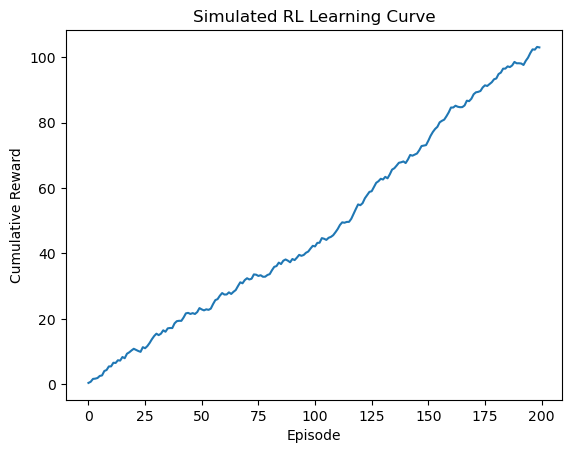

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated learning curve
episodes = 200
reward = np.cumsum(np.random.rand(episodes) * 2 - 0.5)  # increasing trend

plt.plot(reward)
plt.title('Simulated RL Learning Curve')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.show()

### What this means
- **Histogram**: Check balance of your data.
- **Bias & Entropy**: See stability and randomness quality over time.
- **Extractor Table**: Compare methods to pick the best.
- **RL Curve**: Understand how the AI learns to choose extraction methods.